In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from pathlib import Path
from functools import cache
from torchmetrics.classification import MulticlassF1Score
from typing import List
from celeb_a_mask_hq import LABELS
import matplotlib.pyplot as plt

In [2]:
original_image_path = Path("./eval-set/images-150/")
all_image_paths = list(original_image_path.glob("*.jpg"))
masks_path = Path("./eval-set/masks-1024/")
mask_transform = transforms.PILToTensor()
image_ids = {image.stem for image in all_image_paths}
image_ids_list = sorted(list(image_ids))
attemps = 3

@cache
def get_mask_ref(image_id: str, return_image: bool) -> torch.Tensor:
    mask_path = masks_path / f"{image_id}.png"
    mask = Image.open(mask_path)
    if return_image:
        return mask
    mask = mask_transform(mask)
    assert mask.dtype == torch.uint8
    assert mask.max() <= 18
    return mask



In [3]:
result_paths = {
    "gemini-pro": Path("./results/gemini-pro-150"),
    "gemini-pro-shuffled": Path("./results/gemini-pro-150-shuffled-label-colors"),
    "gemini": Path("./results/gemini-150"),
    "gpt": Path("./results/gpt-image-150"),
}


def get_mask_pred(image_id: str, model: str, return_image: bool) -> List[torch.Tensor]:
    result_path = result_paths[model]
    masks = []
    for i in range(attemps):
        mask_path = result_path / f"{image_id}.mask.{i}.pred.png"
        mask = Image.open(mask_path)
        if return_image:
            masks.append(mask)
            continue
        mask = mask_transform(mask)
        assert mask.dtype == torch.uint8
        assert mask.max() <= 18
        masks.append(mask)
    return masks

In [4]:
model = "gemini-pro"
result_path = result_paths[model]
label_num = len(LABELS)

f1_scores = []
for image_id in image_ids_list:
    mask_ref = get_mask_ref(image_id, return_image=False)
    masks_pred = get_mask_pred(image_id, model, return_image=False)
    assert mask_ref.shape == masks_pred[0].shape
    f1_score = torch.empty(attemps)
    for i, mask_pred in enumerate(masks_pred):
        f1 = MulticlassF1Score(num_classes=label_num, average="macro")(mask_pred, mask_ref)
        f1_score[i] = f1
    f1_scores.append(f1_score)

In [5]:
f1_scores = torch.stack(f1_scores)
f1_scores.shape

torch.Size([150, 3])

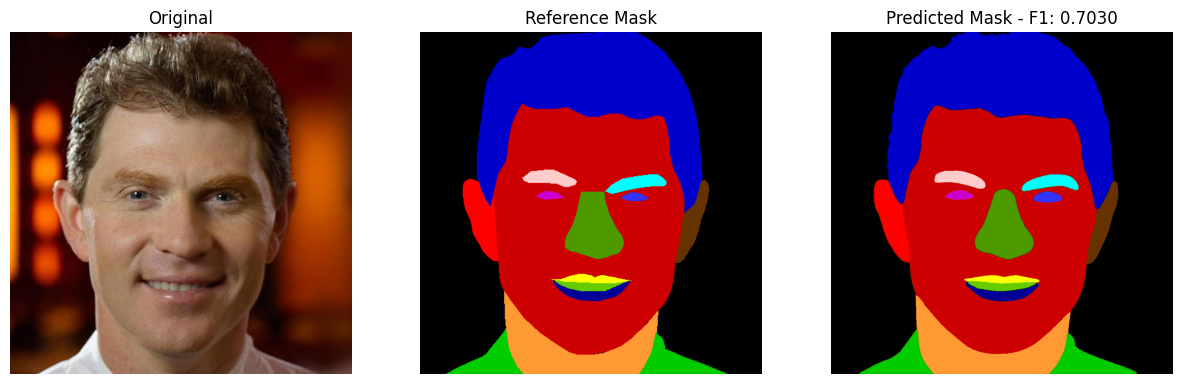

In [6]:
m = f1_scores.max(dim=1)
max_scores = m.values
max_f1 = max_scores.max()
max_column_indices = m.indices
# row for image, column for attemps
max_row_index = max_scores.argmax()
max_col_index = max_column_indices[max_row_index]
best_image_id = image_ids_list[max_row_index.item()]
best_attempt = max_col_index.item()

image = Image.open(original_image_path / f"{best_image_id}.jpg")
mask_ref = get_mask_ref(best_image_id, return_image=True)
mask_pred = get_mask_pred(best_image_id, model, return_image=True)[best_attempt]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(mask_ref)
axes[1].set_title('Reference Mask')
axes[1].axis('off')
axes[2].imshow(mask_pred)
axes[2].set_title(f'Predicted Mask - F1: {max_f1:.4f}')
axes[2].axis('off')
plt.show()


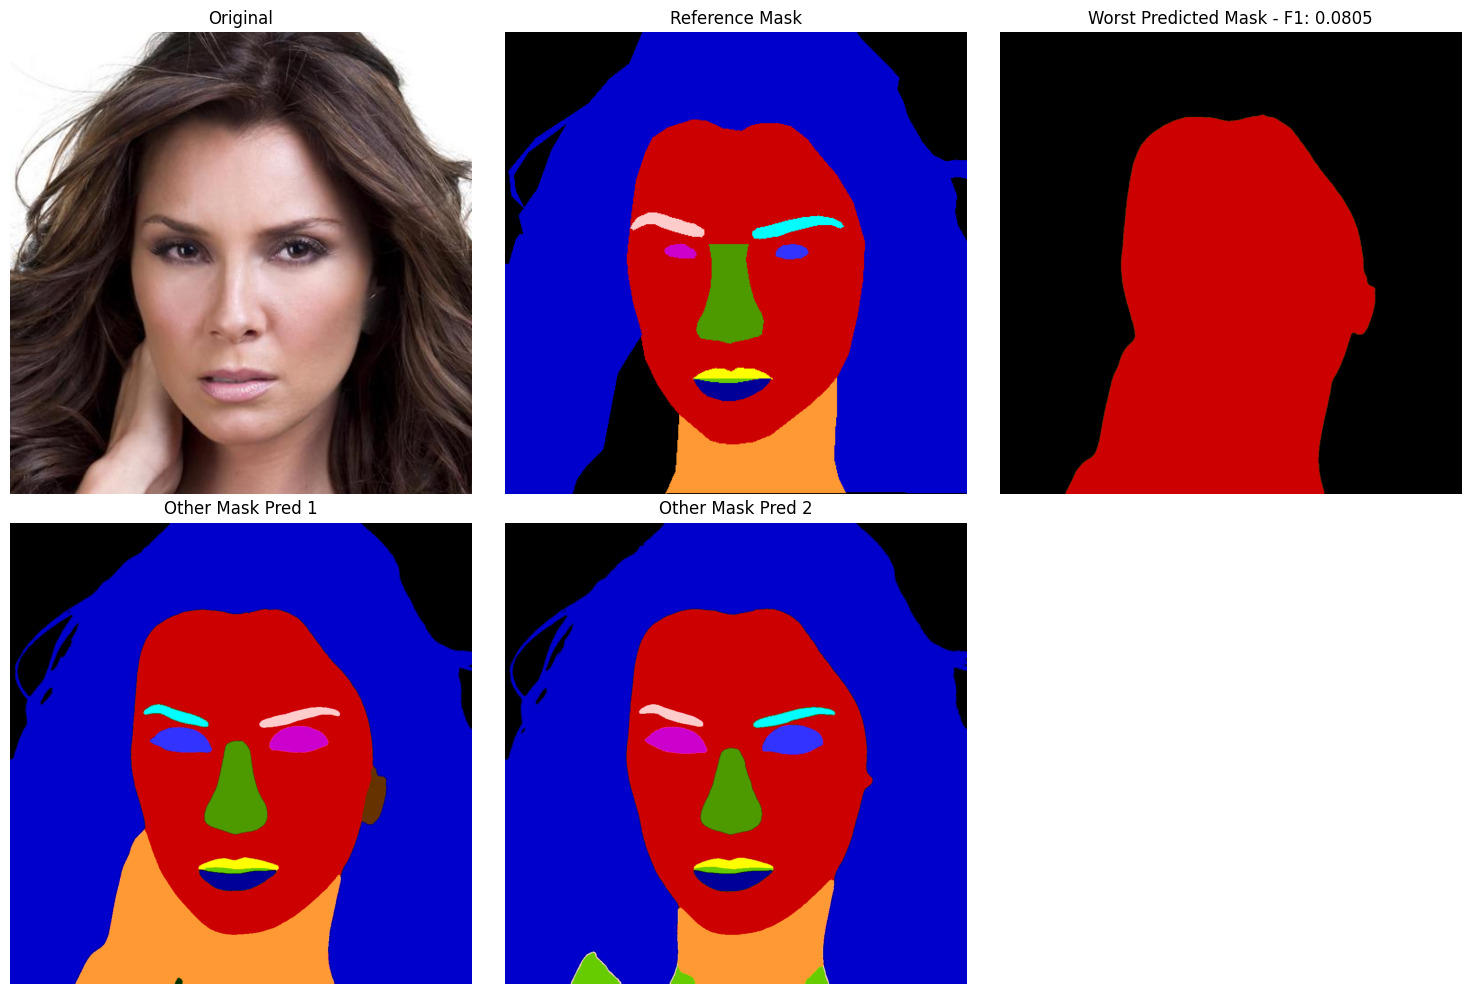

In [7]:
m = f1_scores.min(dim=1)
min_scores = m.values
min_f1 = min_scores.min()
min_column_indices = m.indices
# row for image, column for attemps
min_row_index = min_scores.argmin()
min_col_index = min_column_indices[min_row_index]
worst_image_id = image_ids_list[min_row_index.item()]
worst_attempt = min_col_index.item()

image = Image.open(original_image_path / f"{worst_image_id}.jpg")
mask_ref = get_mask_ref(worst_image_id, return_image=True)
mask_preds = get_mask_pred(worst_image_id, model, return_image=True)
worst_mask_pred = mask_preds[worst_attempt]
other_mask_preds = [mask_preds[i] for i in range(attemps) if i != worst_attempt]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# First row: original, reference, worst predicted
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_ref)
axes[0, 1].set_title('Reference Mask')
axes[0, 1].axis('off')

axes[0, 2].imshow(worst_mask_pred)
axes[0, 2].set_title(f'Worst Predicted Mask - F1: {min_f1:.4f}')
axes[0, 2].axis('off')

# Second row: the other 2 mask preds
for idx, mask in enumerate(other_mask_preds):
    axes[1, idx].imshow(mask)
    axes[1, idx].set_title(f'Other Mask Pred {idx+1}')
    axes[1, idx].axis('off')

# Hide any unused axes in the second row (in case attemps < 3)
for idx in range(len(other_mask_preds), 3):
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()
